# Group Assignment
# Predictive Analytics
# Bank Customer Churn Dataset

This is a classification problem.



Dataset: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset


Here's a concise summary of the notebook:

---

This notebook focuses on predicting customer churn using the Bank Customer Churn Dataset. The workflow includes data preprocessing, feature engineering, model training, evaluation, and optimisation. Key highlights:

1. **Data Preprocessing**:
    - Null values were checked, and unnecessary columns like `customer_id` were dropped.
    - Categorical variables (`country`, `gender`) were one-hot encoded, and numerical features were scaled using `StandardScaler`.
    - Skewed data in the `balance` column was log-transformed to improve model performance.

2. **Exploratory Data Analysis (EDA)**:
    - Basic visualisations (e.g., histograms, correlation heatmap) provided insights into feature distributions and relationships.

3. **Model Training**:
    - Four models were trained: SVM, Random Forest, Logistic Regression, and KNN.
    - Hyperparameter tuning was performed using `GridSearchCV` with `StratifiedKFold` cross-validation.


4. **Key Results**:
    - SVM had the highest recall which is most essential in our task to identify actual bank churners
    - Random Forest achieved the highest cross-validation score (85.14%) and test accuracy (85.8%) and precision.
    - Thus, we can use both SVM and RF models to use for their high recall and accuracy & precision.  
    - Overfitting was minimal across models.
    - XGBoost was applied for boosting, achieving a test accuracy of 86.3% and an AUC of 0.86. Thus, not much of an improvement. 

5. **Evaluation**:
    - Metrics such as accuracy, precision, recall, F1-score, and AUC were calculated for all models.
    - ROC curves were plotted to compare model performance visually.

6. **Ensemble Techniques**:
    - Bagging and boosting were explored to improve model robustness and reduce overfitting.

Overall, the notebook demonstrates a comprehensive approach to building and evaluating predictive models for customer churn, with SVM (recall) Random Forest (accuracy, precision) emerging as top-performing models.

In [1]:
import polars as pl 
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
import torch
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
# import torch.nn as nn
# import torch.optim as optim

Following the group assigment brief, you need to demonstrate you can 

(1) pre-process the data, 

(2) identify appropriate techniques to build and evaluate predictive models (at least 3: e.g., LogsRegression, SVM, Decision Trees, Random Forest,
XGBoost, and Neural Networks), and 

(3) draw conclusions based on your results.

## Pre-process Data

In [2]:
df = pl.read_csv('Bank Customer Churn Prediction.csv')
df 

# our dependent variable/target (y) is 'churn' column

customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
i64,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64
15634602,619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88,1
15647311,608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0
15619304,502,"""France""","""Female""",42,8,159660.8,3,1,0,113931.57,1
15701354,699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63,0
15737888,850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0
…,…,…,…,…,…,…,…,…,…,…,…
15606229,771,"""France""","""Male""",39,5,0.0,2,1,0,96270.64,0
15569892,516,"""France""","""Male""",35,10,57369.61,1,1,1,101699.77,0
15584532,709,"""France""","""Female""",36,7,0.0,1,0,1,42085.58,1


In [3]:
# check for null values 
df.null_count()

customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
# check stats of each quantitative col 
df.describe().with_columns(pl.col(pl.Float64).round(2))

statistic,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",10000.0,10000.0,"""10000""","""10000""",10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
"""null_count""",0.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.5691e7,650.53,null,null,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
"""std""",71936.19,96.65,null,null,10.49,2.89,62397.41,0.58,0.46,0.5,57510.49,0.4
"""min""",1.5565701e7,350.0,"""France""","""Female""",18.0,0.0,0.0,1.0,0.0,0.0,11.58,0.0
"""25%""",1.562853e7,584.0,null,null,32.0,3.0,0.0,1.0,0.0,0.0,51011.29,0.0
"""50%""",1.5690743e7,652.0,null,null,37.0,5.0,97208.46,1.0,1.0,1.0,100200.4,0.0
"""75%""",1.5753229e7,718.0,null,null,44.0,7.0,127642.44,2.0,1.0,1.0,149384.43,0.0
"""max""",1.581569e7,850.0,"""Spain""","""Male""",92.0,10.0,250898.09,4.0,1.0,1.0,199992.48,1.0


In [5]:
df = df.drop(['customer_id']) # I drop 'customer_id' cos it's not necessary for our model
df 

credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64
619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88,1
608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0
502,"""France""","""Female""",42,8,159660.8,3,1,0,113931.57,1
699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63,0
850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0
…,…,…,…,…,…,…,…,…,…,…
771,"""France""","""Male""",39,5,0.0,2,1,0,96270.64,0
516,"""France""","""Male""",35,10,57369.61,1,1,1,101699.77,0
709,"""France""","""Female""",36,7,0.0,1,0,1,42085.58,1


## Notice: I wanna see the categorical cols and target cols unique values and counts. I will hot encode these later.

In [6]:
df['country'].unique() # 3 unique vals

country
str
"""Germany"""
"""France"""
"""Spain"""


In [7]:
df.group_by('country').agg(pl.count('country').alias('count')).sort('count', descending=True)

country,count
str,u32
"""France""",5014
"""Germany""",2509
"""Spain""",2477


In [8]:
df['gender'].unique() # 2 unique vals

gender
str
"""Male"""
"""Female"""


In [9]:
df.group_by('gender').agg(pl.count('gender').alias('count')).sort('count', descending=True)

gender,count
str,u32
"""Male""",5457
"""Female""",4543


In [10]:
df['churn'].unique() # 2 unique vals

churn
i64
0
1


In [11]:
churn_counts = df.group_by('churn').agg(pl.count('churn').alias('count')).sort('count', descending=True)
total_count = churn_counts['count'].sum()
churn_counts = churn_counts.with_columns((pl.col('count') / total_count * 100).alias('percentage'))
churn_counts

churn,count,percentage
i64,u32,f64
0,7963,79.63
1,2037,20.37


In [12]:
# target is moderately imbalanced (~80% no churn 0, ~20% churn 1)
# Rectified imbalance by: 
# 1. StratifiedKFold
# 2. class_weight='balanced' for models' parameter 

# Basic EDA 

## Note: Do not focus your writing on EDA as it is not needed as per project brief but I made a basic one just to visualise an overview of data

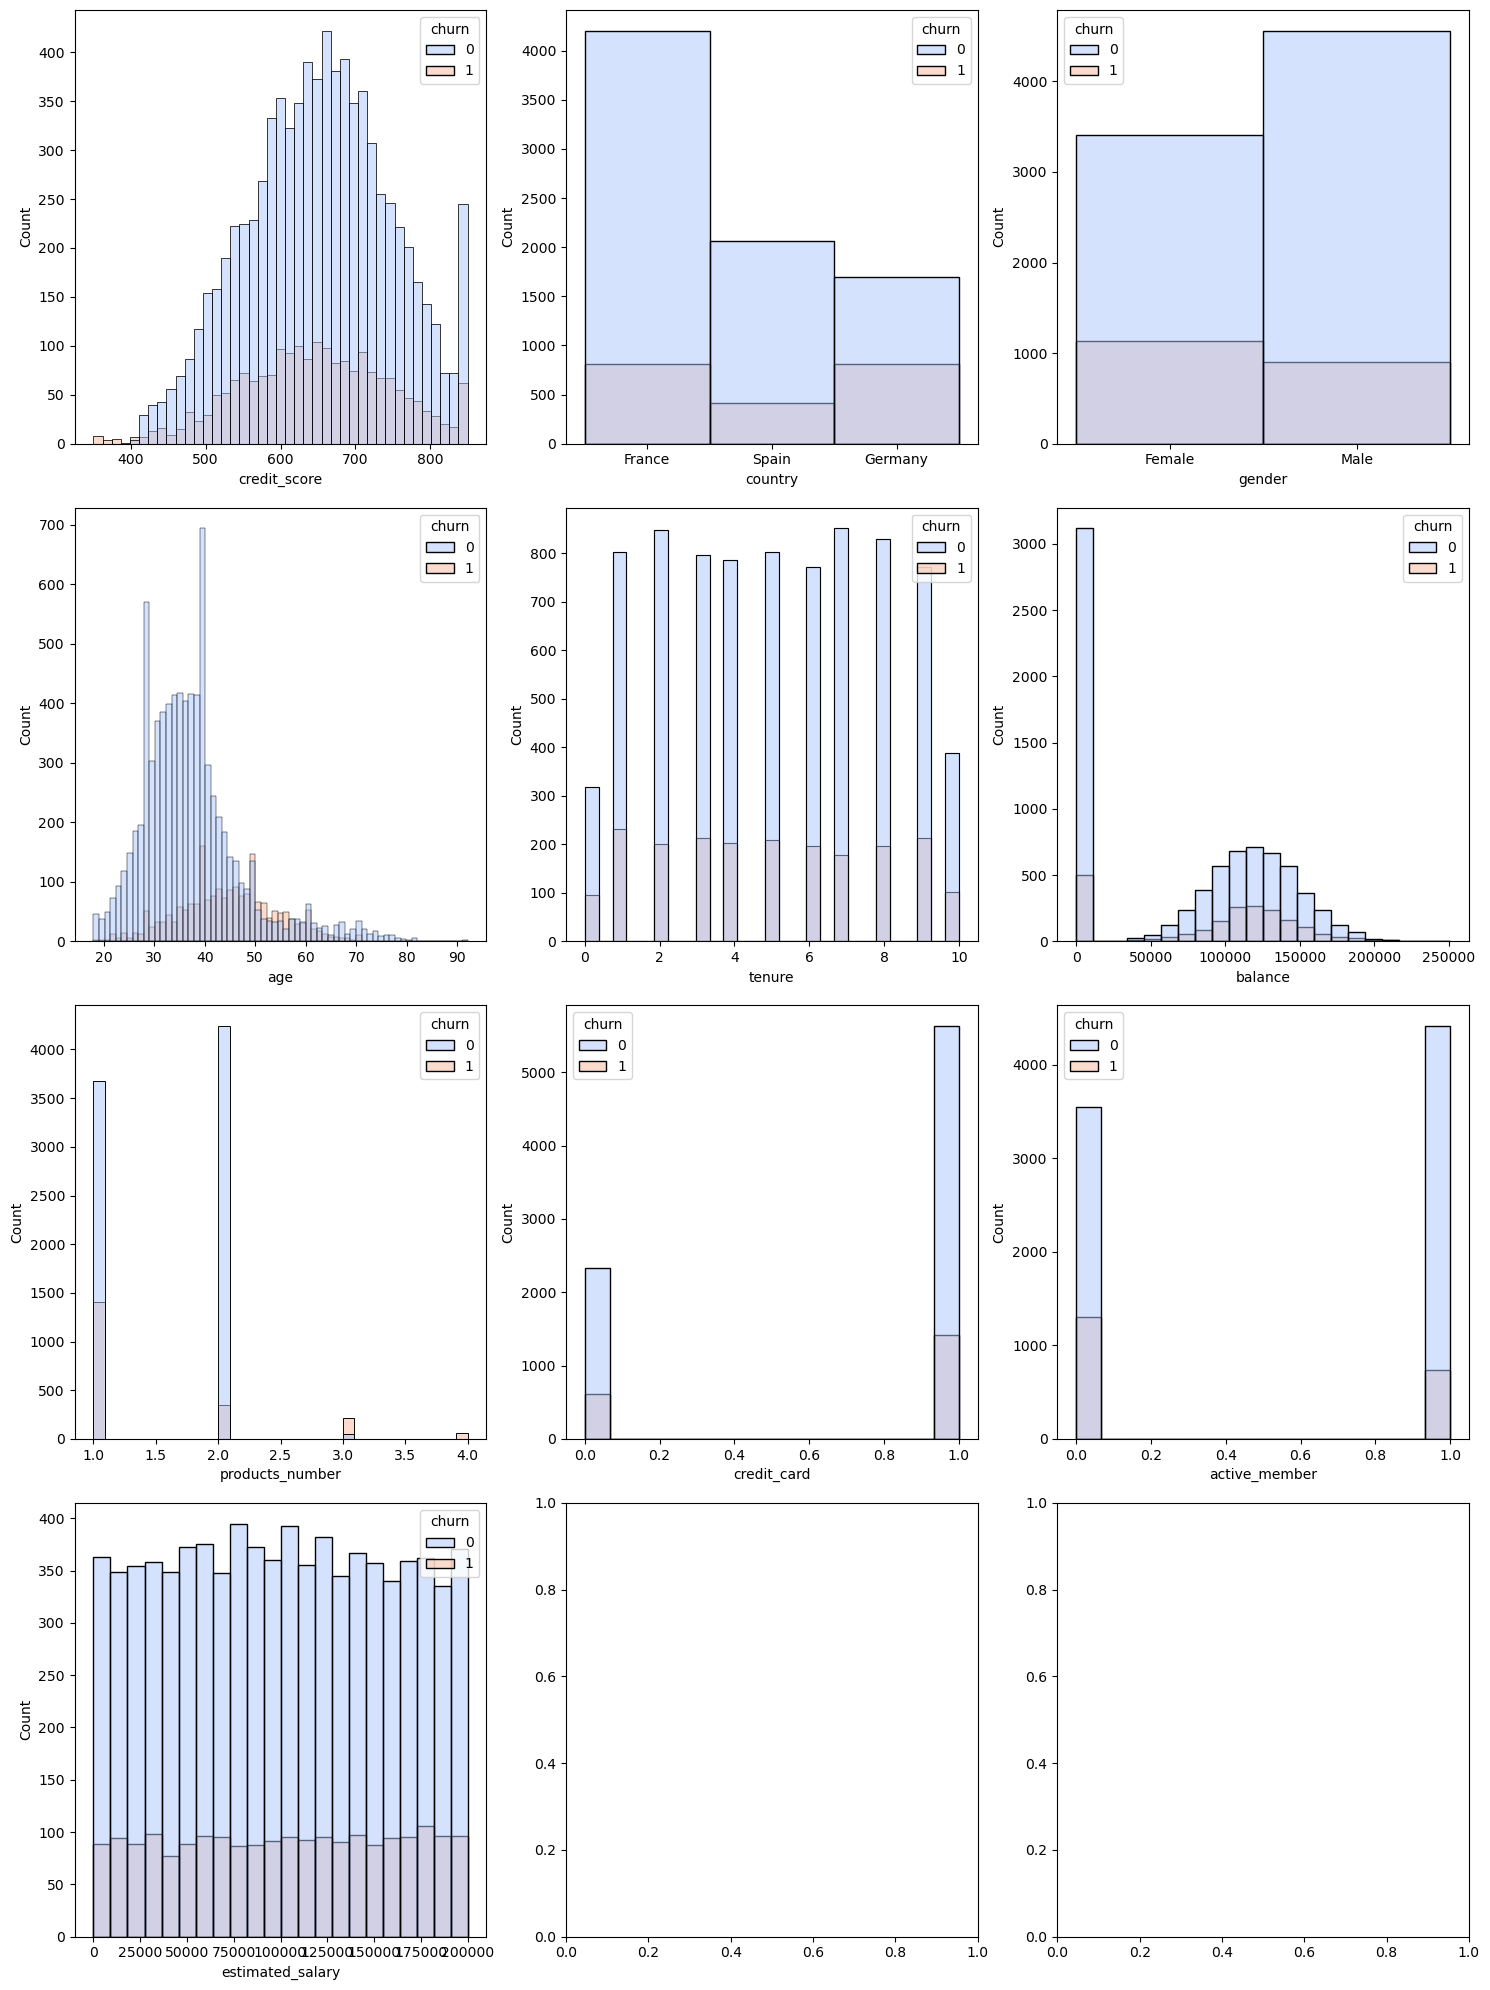

In [13]:
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15,20))
axs = axs.flat
for i in range(len(df.columns) - 1):
    sns.histplot(data=df.to_pandas(), x=df.columns[i], hue="churn", ax=axs[i], palette="coolwarm")
plt.tight_layout()
plt.show()

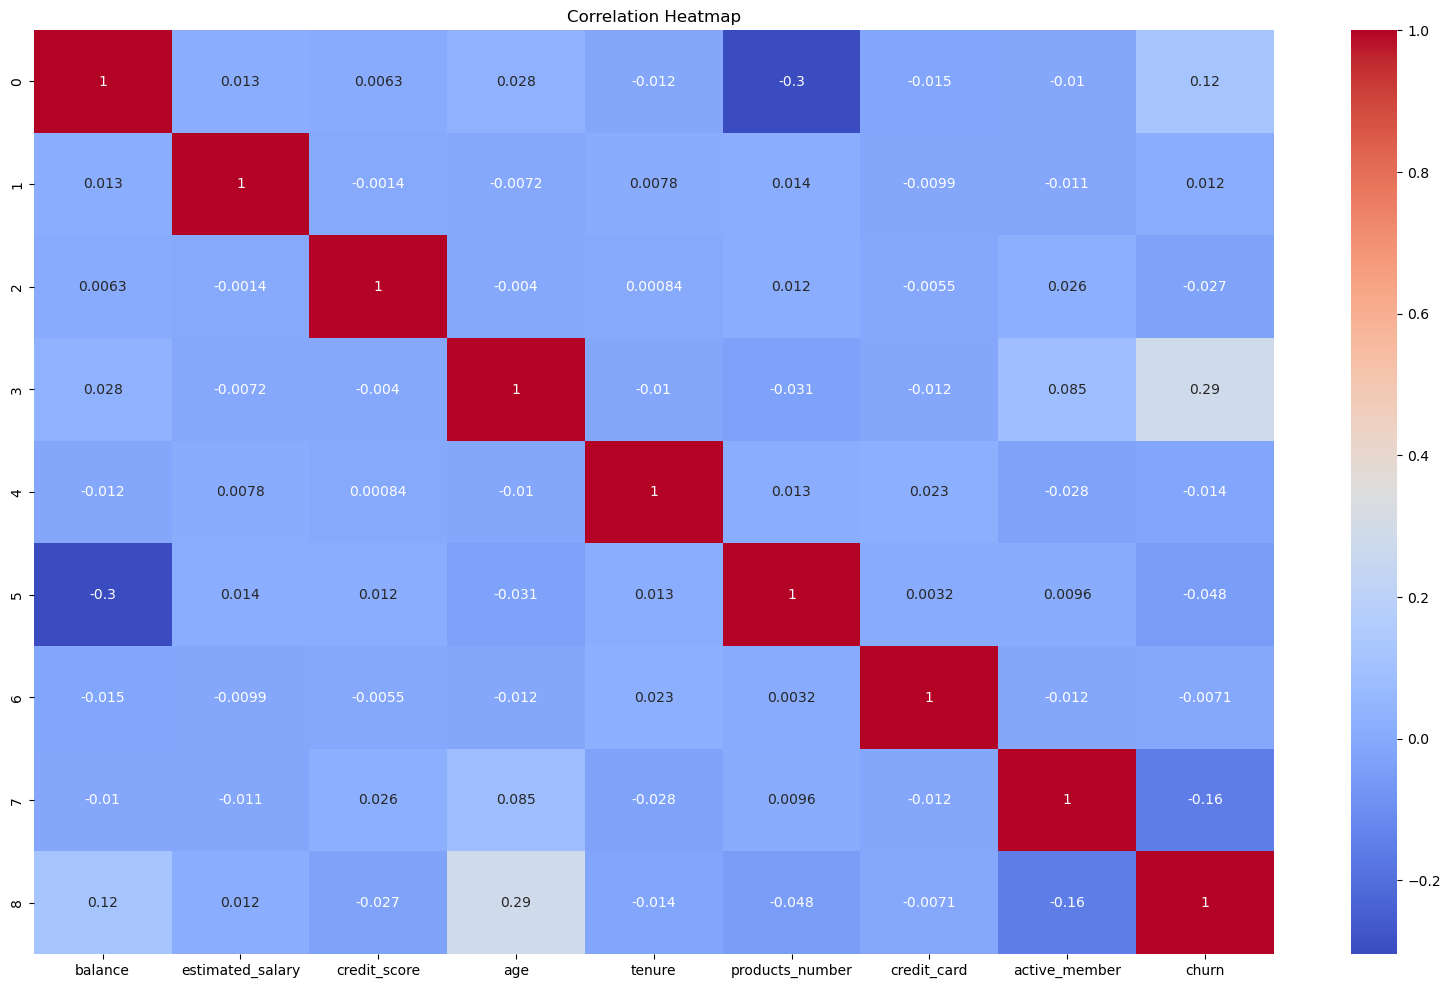

In [14]:
numeric_df = df.select([pl.col(pl.Float64), pl.col(pl.Int64)])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix.to_pandas(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Set Dependent (y) and Independent Variables (X) for Modelling

In [15]:
X = df.drop('churn')
y = df['churn']

In [16]:
X.shape, y.shape

((10000, 10), (10000,))

In [17]:
X.columns

['credit_score',
 'country',
 'gender',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary']

In [18]:
y.head(1)

churn
i64
1


# Feature Engineering

1. Encode Categorical Cols

2. Scale Numerical Cols

In [19]:
X.head()

credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
i64,str,str,i64,i64,f64,i64,i64,i64,f64
619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88
608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58
502,"""France""","""Female""",42,8,159660.8,3,1,0,113931.57
699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63
850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1


In [20]:
X = X.to_dummies('country')
X = X.drop('country_Spain')
X.head()

credit_score,country_France,country_Germany,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
i64,u8,u8,str,i64,i64,f64,i64,i64,i64,f64
619,1,0,"""Female""",42,2,0.0,1,1,1,101348.88
608,0,0,"""Female""",41,1,83807.86,1,0,1,112542.58
502,1,0,"""Female""",42,8,159660.8,3,1,0,113931.57
699,1,0,"""Female""",39,1,0.0,2,0,0,93826.63
850,0,0,"""Female""",43,2,125510.82,1,1,1,79084.1


In [21]:
X = X.to_dummies('gender')
X = X.drop('gender_Female')
X.head()

credit_score,country_France,country_Germany,gender_Male,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
i64,u8,u8,u8,i64,i64,f64,i64,i64,i64,f64
619,1,0,0,42,2,0.0,1,1,1,101348.88
608,0,0,0,41,1,83807.86,1,0,1,112542.58
502,1,0,0,42,8,159660.8,3,1,0,113931.57
699,1,0,0,39,1,0.0,2,0,0,93826.63
850,0,0,0,43,2,125510.82,1,1,1,79084.1


In [22]:
# address the skewed data in 'balance' column by applying log transformation
# I used log1p to avoid log(0) error when balance = 0 
# this should improve model performance since models assume relatively normally distributed data
# especially for linear models like logistic regression, distance based models like SVM or KNN, and neural networks


X = X.with_columns(
    pl.col("balance").log1p().alias("log_balance")
)
X

credit_score,country_France,country_Germany,gender_Male,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,log_balance
i64,u8,u8,u8,i64,i64,f64,i64,i64,i64,f64,f64
619,1,0,0,42,2,0.0,1,1,1,101348.88,0.0
608,0,0,0,41,1,83807.86,1,0,1,112542.58,11.336294
502,1,0,0,42,8,159660.8,3,1,0,113931.57,11.980813
699,1,0,0,39,1,0.0,2,0,0,93826.63,0.0
850,0,0,0,43,2,125510.82,1,1,1,79084.1,11.740155
…,…,…,…,…,…,…,…,…,…,…,…
771,1,0,1,39,5,0.0,2,1,0,96270.64,0.0
516,1,0,1,35,10,57369.61,1,1,1,101699.77,10.957287
709,1,0,0,36,7,0.0,1,0,1,42085.58,0.0


In [23]:
X = X.drop('balance')
X 

credit_score,country_France,country_Germany,gender_Male,age,tenure,products_number,credit_card,active_member,estimated_salary,log_balance
i64,u8,u8,u8,i64,i64,i64,i64,i64,f64,f64
619,1,0,0,42,2,1,1,1,101348.88,0.0
608,0,0,0,41,1,1,0,1,112542.58,11.336294
502,1,0,0,42,8,3,1,0,113931.57,11.980813
699,1,0,0,39,1,2,0,0,93826.63,0.0
850,0,0,0,43,2,1,1,1,79084.1,11.740155
…,…,…,…,…,…,…,…,…,…,…
771,1,0,1,39,5,2,1,0,96270.64,0.0
516,1,0,1,35,10,1,1,1,101699.77,10.957287
709,1,0,0,36,7,1,0,1,42085.58,0.0


### Scaler

In [24]:
scaler = StandardScaler()
X[["credit_score", "age", "estimated_salary", "log_balance", "tenure"]] = scaler.fit_transform(X[["credit_score", "age", "estimated_salary", "log_balance", "tenure"]])

In [25]:
X

credit_score,country_France,country_Germany,gender_Male,age,tenure,products_number,credit_card,active_member,estimated_salary,log_balance
f64,u8,u8,u8,f64,f64,i64,i64,i64,f64,f64
-0.326221,1,0,0,0.293517,-1.04176,1,1,1,0.021886,-1.327358
-0.440036,0,0,0,0.198164,-1.387538,1,0,1,0.216534,0.694771
-1.536794,1,0,0,0.293517,1.032908,3,1,0,0.240687,0.809738
0.501521,1,0,0,0.007457,-1.387538,2,0,0,-0.108918,-1.327358
2.063884,0,0,0,0.388871,-1.04176,1,1,1,-0.365276,0.76681
…,…,…,…,…,…,…,…,…,…,…
1.246488,1,0,1,0.007457,-0.004426,2,1,0,-0.066419,-1.327358
-1.391939,1,0,1,-0.373958,1.724464,1,1,1,0.027988,0.627165
0.604988,1,0,0,-0.278604,0.68713,1,0,1,-1.008643,-1.327358


# Create the Models

The models will involve classification models:

In [26]:
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# for train_index, test_index in kf.split(X):
#     X_train, X_test = X[train_index], X[test_index]
#     y_train, y_test = y[train_index], y[test_index]


In [27]:
# X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [28]:
# start creating models

In [29]:
# # Make a neural net class definition here, to be included in pipeline later, along with classical ML models in Gridsearch
# class NeuralNetwork(nn.Module):
#     def __init__(self, input_size):
#         super(NeuralNetwork, self).__init__()
#         self.fc1 = nn.Linear(input_size, 64)
#         self.relu = nn.ReLU()
#         self.fc2 = nn.Linear(64, 32)
#         self.fc3 = nn.Linear(32, 1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         x = self.fc1(x)
#         x = self.relu(x)
#         x = self.fc2(x)
#         x = self.relu(x)
#         x = self.fc3(x)
#         x = self.sigmoid(x)
#         return x


In [30]:
# # Here, I define a PyTorch model wrapper -> for compatibility with sklearn
# class PyTorchModel:
#     def __init__(self, input_size, lr=0.001, epochs=10):
#         self.model = NeuralNetwork(input_size)
#         self.criterion = nn.BCELoss()
#         self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
#         self.epochs = epochs

#     def fit(self, X, y):
#         X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
#         y_tensor = torch.tensor(y.to_numpy(), dtype=torch.float32).view(-1, 1)
#         for epoch in range(self.epochs):
#             self.optimizer.zero_grad()
#             outputs = self.model(X_tensor)
#             loss = self.criterion(outputs, y_tensor)
#             loss.backward()
#             self.optimizer.step()

#     def predict(self, X):
#         X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
#         with torch.no_grad():
#             outputs = self.model(X_tensor)
#         return (outputs.numpy() > 0.5).astype(int)

In [31]:
# param_grid = [
#     {
#         'model': [LogisticRegression()],
#         'model__C': [0.01, 0.1, 1, 10, 100],
#         'model__solver': ['liblinear', 'lbfgs'],
#         'model__max_iter': [100, 200, 500]  
#     },
#     {
#         'model': [RandomForestClassifier()],
#         'model__n_estimators': [50, 100, 200, 300],
#         'model__max_depth': [None, 10, 20, 30],
#         'model__min_samples_split': [2, 5, 10],
#         'model__min_samples_leaf': [1, 2, 4],
#         'model__bootstrap': [True, False]  
#     },
#     {
#         'model': [SVC()],
#         'model__C': [0.01, 0.1, 1, 10],
#         'model__kernel': ['linear', 'rbf', 'poly'],
#         'model__gamma': ['scale', 'auto'],
#         'model__degree': [2, 3, 4]  
#     },
#     {
#         'model': [KNeighborsClassifier()],
#         'model__n_neighbors': [3, 5, 7, 9],
#         'model__weights': ['uniform', 'distance'],
#         'model__metric': ['minkowski', 'euclidean', 'manhattan'],
#         'model__p': [1, 2]  
#     } #,
#     # {
#     #     'model': [PyTorchModel(input_size=X.shape[1])],
#     #     'model__lr': [0.001, 0.01, 0.1],
#     #     'model__epochs': [10, 20, 30],
#     #     'model__batch_size': [16, 32, 64],
#     #     'model__dropout': [0.2, 0.5]  
#     # }
# ]

In [32]:
# # Create a pipeline
# pipeline = Pipeline([
#     ('model', LogisticRegression())  # Placeholder, will be replaced by GridSearchCV
# ])

In [33]:
# # Perform grid search
# grid_search = GridSearchCV(pipeline, param_grid, cv=kf, scoring=make_scorer(accuracy_score))
# grid_search.fit(X_train, y_train)

# # Print the best model and parameters
# print("Best Model:", grid_search.best_estimator_)
# print("Best Parameters:", grid_search.best_params_)
# print("Best Score:", grid_search.best_score_)

In [34]:
# Best Model: Pipeline(steps=[('model',
#                  RandomForestClassifier(max_depth=30, min_samples_leaf=2,
#                                         n_estimators=50))])
# Best Parameters: {'model': RandomForestClassifier(max_depth=30, min_samples_leaf=2, n_estimators=50), 'model__bootstrap': True, 'model__max_depth': 30, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 50}
# Best Score: 0.864625

In [35]:

# # Extract results from GridSearchCV
# results = pd.DataFrame(grid_search.cv_results_)

# # Select relevant columns and sort by mean test score in descending order
# ranked_models = results[['rank_test_score', 'mean_test_score', 'param_model']].sort_values(by='rank_test_score')

# # Display the ranked models
# ranked_models

In [36]:
# ranked_models.to_csv('ranked_models.csv', index=False)

In [37]:
model_params = {
    'svm':{
        'model': SVC(probability=True, class_weight='balanced'),
        'params': {
            'C': [1,10,20],
            'kernel': ['rbf', 'linear', 'poly'],
            'gamma': ['scale', 'auto'],
            'degree': [2,3,4]
        }
    },
    'random_forest':{
        'model': RandomForestClassifier(class_weight='balanced'),
        'params': {
            'n_estimators': [1,5,10],
            'max_depth': [None, 10,20,30],
            'min_samples_split': [2,5,10],
            'min_samples_leaf': [1,2,4],
            'bootstrap': [True, False]
        } 
    },
    'logistic_regression':{
        'model': LogisticRegression(class_weight='balanced'),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs'],
            'max_iter': [100, 200, 500]
        }
    }, 
    'knn':{
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'metric': ['minkowski', 'euclidean', 'manhattan'],
            'p': [1, 2]
        }
    }
    
}


In [38]:
scores = []

for key, value in model_params.items():
    
    # Use StratifiedKFold for cross-validation
    stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf = GridSearchCV(value['model'], value['params'], cv=stratified_kf, return_train_score=False)
    clf.fit(X, y)
    scores.append({
        'model': key, 
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

In [39]:


# # Update the grid search to include SMOTE in the pipeline
# scores_with_smote = []

# for key, value in model_params.items():
#     # Create a pipeline with SMOTE and the model
#     pipeline = ImbPipeline([
#         ('smote', SMOTE(random_state=42)),
#         ('model', value['model'])
#     ])
    
#     # Update parameter names to include the pipeline step
#     updated_params = {f"model__{param}": val for param, val in value['params'].items()}
    
#     # Perform grid search with the pipeline
#     clf = GridSearchCV(pipeline, updated_params, cv=5, return_train_score=False)
#     clf.fit(X_train, y_train)
    
#     scores_with_smote.append({
#         'model': key, 
#         'best_score': clf.best_score_,
#         'best_params': clf.best_params_
#     })

# # Convert the results to a DataFrame for better visualization
# scores_with_smote_df = pd.DataFrame(scores_with_smote)
# print(scores_with_smote_df)

In [40]:
# # Initialize a list to store the results
# smote_metrics_results = []

# # Iterate through the best models in 'scores_with_smote'
# for score in scores_with_smote:
#     model_name = score['model']
#     best_params = score['best_params']
    
#     # Initialize the model with the best parameters
#     model = model_params[model_name]['model'].set_params(**{param.split('__')[1]: value for param, value in best_params.items()})
#     model.fit(X_train, y_train)
    
#     # Predict on the test set
#     y_pred = model.predict(X_test)
    
#     # Calculate metrics
#     accuracy = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     recall = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)
    
#     # Append the results
#     smote_metrics_results.append({
#         'model': model_name,
#         'accuracy': accuracy,
#         'precision': precision,
#         'recall': recall,
#         'f1_score': f1
#     })

# # Convert the results to a DataFrame for better visualization
# smote_metrics_df = pd.DataFrame(smote_metrics_results)
# print(smote_metrics_df)

In [41]:
scores

[{'model': 'svm',
  'best_score': 0.7983,
  'best_params': {'C': 1, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}},
 {'model': 'random_forest',
  'best_score': 0.8539000000000001,
  'best_params': {'bootstrap': True,
   'max_depth': 30,
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 10}},
 {'model': 'logistic_regression',
  'best_score': 0.7192000000000001,
  'best_params': {'C': 0.01, 'max_iter': 100, 'solver': 'liblinear'}},
 {'model': 'knn',
  'best_score': 0.8351,
  'best_params': {'metric': 'minkowski',
   'n_neighbors': 9,
   'p': 2,
   'weights': 'uniform'}}]

In [42]:
scores_df = pl.DataFrame(scores, schema=['model', 'best_score', 'best_params'])
scores_df

model,best_score,best_params
str,f64,struct[15]
"""svm""",0.7983,"{null,null,null,null,null,1.0,2,""auto"",""rbf"",null,null,null,null,null,null}"
"""random_forest""",0.8539,"{true,30,1,2,10,null,null,null,null,null,null,null,null,null,null}"
"""logistic_regression""",0.7192,"{null,null,null,null,null,0.01,null,null,null,100,""liblinear"",null,null,null,null}"
"""knn""",0.8351,"{null,null,null,null,null,null,null,null,null,null,null,""minkowski"",9,2,""uniform""}"


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X.to_pandas(), y.to_pandas(), test_size=0.2, random_state=42)

metrics_results = []

for score in scores:
    model_name = score['model']
    best_params = score['best_params']
    
    model = model_params[model_name]['model'].set_params(**best_params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    metrics_results.append({
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

metrics_df = pd.DataFrame(metrics_results)
print(metrics_df)

                 model  accuracy  precision    recall  f1_score
0                  svm    0.7875   0.474441  0.755725  0.582924
1        random_forest    0.8585   0.741228  0.430025  0.544283
2  logistic_regression    0.7300   0.396040  0.712468  0.509091
3                  knn    0.8435   0.715054  0.338422  0.459413


Using GridSearchCV with `cv=5` helps reduce overfitting by evaluating the model's performance on multiple folds of the data, ensuring it generalizes well across different subsets. However, it does not completely eliminate overfitting. Overfitting can still occur if the model is too complex or if the hyperparameters are tuned too specifically to the training data.

To test for overfitting, you can:

1. **Evaluate on a Separate Test Set**:
    After performing cross-validation, evaluate the model on a separate test set that was not used during training or validation. If the performance on the test set is significantly worse than on the training/validation set, the model may be overfitting.

2. **Compare Training and Validation Scores**:
    During cross-validation, compare the training and validation scores. If the training score is much higher than the validation score, it indicates overfitting.

3. **Learning Curve Analysis**:
    Plot learning curves to observe how the training and validation scores change with increasing training data. Overfitting is indicated if the training score is high while the validation score remains low.

4. **Regularization**:
    Use regularization techniques (e.g., L1/L2 regularization) to penalize overly complex models and reduce overfitting.

5. **Simplify the Model**:
    Reduce the complexity of the model (e.g., fewer layers in a neural network, fewer trees in a random forest, etc.).

6. **Cross-Validation on Multiple Splits**:
    Use different cross-validation strategies (e.g., `StratifiedKFold`) to ensure the model generalizes well across various data splits.

Would you like me to demonstrate any of these techniques?

## Test for Overfitting

In [44]:
# X_train, X_test, y_train, y_test = train_test_split(X.to_pandas(), y.to_pandas(), test_size=0.2, random_state=42)

overfitting_results = []

for score in scores:
    model_name = score['model']
    best_params = score['best_params']
    
    model = model_params[model_name]['model'].set_params(**best_params)
    model.fit(X_train, y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    overfitting_results.append({
        'model': model_name,
        'train_score': train_score,
        'test_score': test_score,
        'overfitting_gap': train_score - test_score
    })

overfitting_df = pd.DataFrame(overfitting_results)
print(overfitting_df)

                 model  train_score  test_score  overfitting_gap
0                  svm     0.809000      0.7875         0.021500
1        random_forest     0.985000      0.8465         0.138500
2  logistic_regression     0.719125      0.7300        -0.010875
3                  knn     0.856125      0.8435         0.012625


## AUC Curve

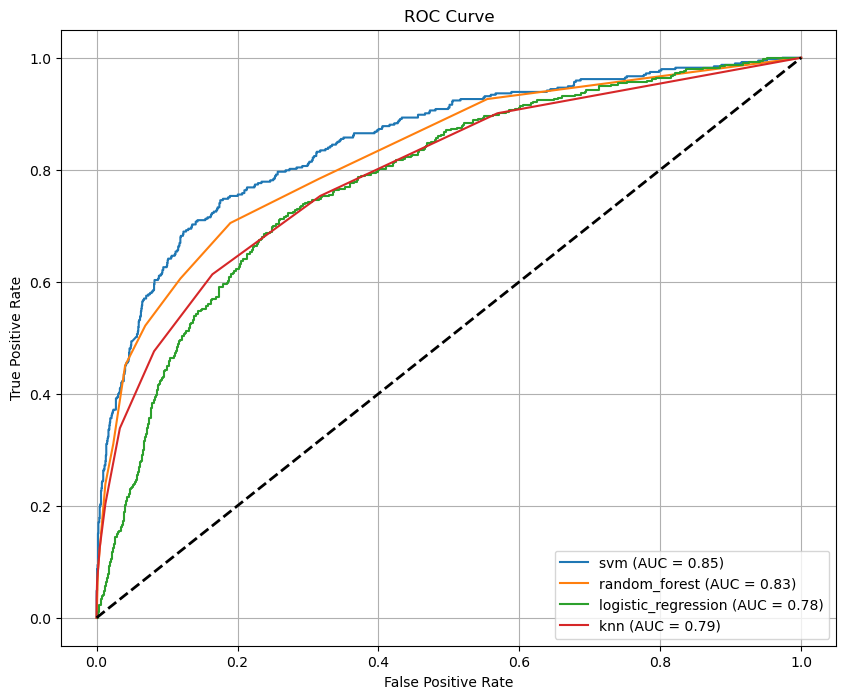

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X.to_pandas(), y.to_pandas(), test_size=0.2, random_state=42)

plt.figure(figsize=(10, 8))

for score in scores:
    model_name = score['model']
    best_params = score['best_params']
    
    model = model_params[model_name]['model'].set_params(**best_params)
    model.fit(X_train, y_train)
    
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Bagging

In [ ]:
# Bagging the best models
bagging_results = []

for score in scores:
    model_name = score['model']
    best_params = score['best_params']
    
    base_model = model_params[model_name]['model'].set_params(**best_params)
    
    bagging_model = BaggingClassifier(base_model, n_estimators=10, random_state=42)
    
    bagging_model.fit(X_train, y_train)
    
    train_score = bagging_model.score(X_train, y_train)
    test_score = bagging_model.score(X_test, y_test)
    
    bagging_results.append({
        'model': model_name,
        'train_score': train_score,
        'test_score': test_score,
        'overfitting_gap': train_score - test_score
    })

bagging_results_df = pd.DataFrame(bagging_results)
print(bagging_results_df)

                 model  train_score  test_score  overfitting_gap
0                  svm     0.861250      0.8580         0.003250
1        random_forest     0.958375      0.8615         0.096875
2  logistic_regression     0.720000      0.7280        -0.008000
3                  knn     0.860125      0.8425         0.017625


In [ ]:

bagging_metrics_results = []

for score in bagging_results:
    model_name = score['model']
    best_params = next(item['best_params'] for item in scores if item['model'] == model_name)
    
    base_model = model_params[model_name]['model'].set_params(**best_params)
    
    bagging_model = BaggingClassifier(base_model, n_estimators=10, random_state=42)
    
    bagging_model.fit(X_train, y_train)
    
    y_pred = bagging_model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    bagging_metrics_results.append({
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

bagging_metrics_df = pd.DataFrame(bagging_metrics_results)
print(bagging_metrics_df)

                 model  accuracy  precision    recall  f1_score
0                  svm    0.8580   0.720648  0.452926  0.556250
1        random_forest    0.8615   0.756637  0.435115  0.552504
2  logistic_regression    0.7280   0.393812  0.712468  0.507246
3                  knn    0.8425   0.714286  0.330789  0.452174


In [48]:


# # Boosting the best models
# boosting_results = []

# for score in scores:
#     model_name = score['model']
#     best_params = score['best_params']
    
#     # Initialize the base model with the best parameters
#     base_model = model_params[model_name]['model'].set_params(**best_params)
    
#     # Create an AdaBoostClassifier with the base model
#     boosting_model = AdaBoostClassifier(base_estimator=base_model, n_estimators=50, random_state=42)
    
#     # Fit the boosting model
#     boosting_model.fit(X_train, y_train)
    
#     # Evaluate the boosting model
#     train_score = boosting_model.score(X_train, y_train)
#     test_score = boosting_model.score(X_test, y_test)
    
#     boosting_results.append({
#         'model': model_name,
#         'train_score': train_score,
#         'test_score': test_score,
#         'overfitting_gap': train_score - test_score
#     })

# # Convert results to a DataFrame for better visualization
# boosting_results_df = pd.DataFrame(boosting_results)
# print(boosting_results_df)

# Boosting

In [ ]:

# Boosting the best models using XGBoost
xgboost_results = []

for score in scores:
    model_name = score['model']
    best_params = score['best_params']
    
    base_model = model_params[model_name]['model'].set_params(**best_params)
    
    xgboost_model = XGBClassifier(base_estimator=base_model, n_estimators=50, random_state=42, use_label_encoder=False, eval_metric='logloss')
    
    xgboost_model.fit(X_train, y_train)
    
    train_score = xgboost_model.score(X_train, y_train)
    test_score = xgboost_model.score(X_test, y_test)
    
    xgboost_results.append({
        'model': model_name,
        'train_score': train_score,
        'test_score': test_score,
        'overfitting_gap': train_score - test_score
    })

xgboost_results_df = pd.DataFrame(xgboost_results)
print(xgboost_results_df)

                 model  train_score  test_score  overfitting_gap
0                  svm      0.91875       0.863          0.05575
1        random_forest      0.91875       0.863          0.05575
2  logistic_regression      0.91875       0.863          0.05575
3                  knn      0.91875       0.863          0.05575


/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [16:18:46] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "base_estimator", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [16:18:46] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "base_estimator", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [16:18:46] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "base_estimator", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/pyt

/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [16:18:46] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "base_estimator", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


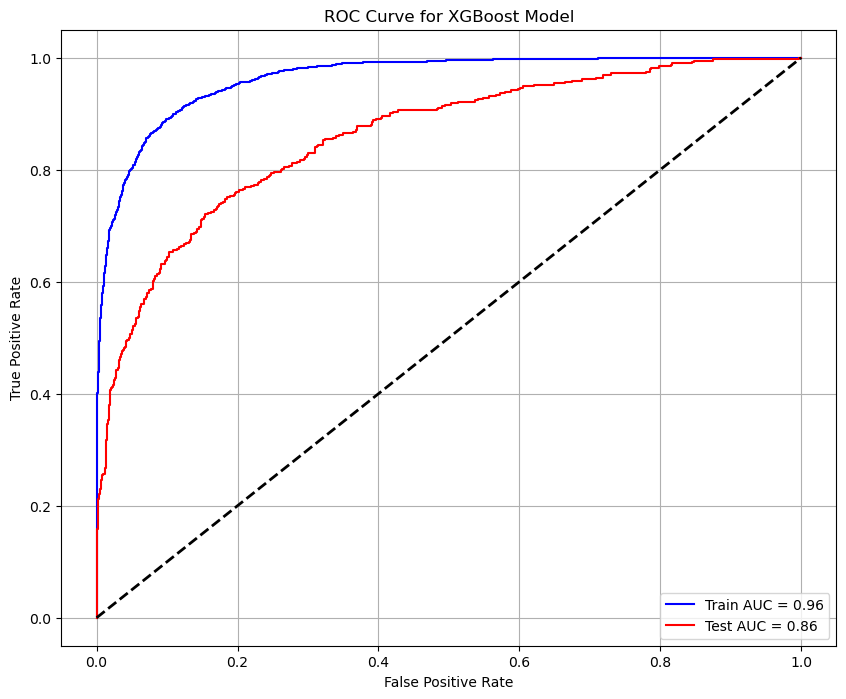

In [ ]:
xgboost_model.fit(X_train, y_train)

y_train_pred_prob = xgboost_model.predict_proba(X_train)[:, 1]
y_test_pred_prob = xgboost_model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, label=f'Train AUC = {roc_auc_train:.2f}', color='blue')
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {roc_auc_test:.2f}', color='red')
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Model')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [51]:
# Calculate metrics for the XGBoost model
xgboost_accuracy = accuracy_score(y_test, xgboost_model.predict(X_test))
xgboost_precision = precision_score(y_test, xgboost_model.predict(X_test))
xgboost_recall = recall_score(y_test, xgboost_model.predict(X_test))
xgboost_f1 = f1_score(y_test, xgboost_model.predict(X_test))

# Display the results
print(f"XGBoost Model Metrics:")
print(f"Accuracy: {xgboost_accuracy:.4f}")
print(f"Precision: {xgboost_precision:.4f}")
print(f"Recall (Sensitivity): {xgboost_recall:.4f}")
print(f"F1-Score: {xgboost_f1:.4f}")

XGBoost Model Metrics:
Accuracy: 0.8630
Precision: 0.7117
Recall (Sensitivity): 0.5089
F1-Score: 0.5935
